# Segundo Examen Parcial — Probabilidad y Estadística para IA

**Nombre:** Jonatan Brian Mild  
**Código:** a2531  
**Docente:** Camilo Argoty

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import seaborn as sns

sns.set(style="whitegrid")

---
## Ejercicio 1 — Máxima verosimilitud (3 puntos)

La variable aleatoria discreta $X$ toma valores $0, 1, 2, 3$ con la siguiente tabla de probabilidades:

| $x$ | $0$ | $1$ | $2$ | $3$ |
|---|---|---|---|---|
| $P(X=x)$ | $\dfrac{3\theta}{3}$ | $\dfrac{6\theta}{3}$ | $\dfrac{1-3\theta}{3}$ | $\dfrac{2(1-3\theta)}{3}$ |

### Paso 1 — Simplificar la función de masa de probabilidad

$$P(X=0) = \frac{3\theta}{3} = \theta$$

$$P(X=1) = \frac{6\theta}{3} = 2\theta$$

$$P(X=2) = \frac{1-3\theta}{3}$$

$$P(X=3) = \frac{2(1-3\theta)}{3}$$

### Paso 2 — Verificar que las probabilidades suman 1

$$\theta + 2\theta + \frac{1-3\theta}{3} + \frac{2(1-3\theta)}{3} = 3\theta + \frac{1-3\theta}{3} + \frac{2(1-3\theta)}{3}$$

$$= 3\theta + \frac{3(1-3\theta)}{3} = 3\theta + (1-3\theta) = 1$$

Para que todas las probabilidades sean no negativas, además se requiere:

$$\theta \geq 0, \qquad 2\theta \geq 0, \qquad 1-3\theta \geq 0 \quad \Longrightarrow \quad 0 \leq \theta \leq \frac{1}{3}$$

### Paso 3 — Contar las frecuencias de la muestra

Datos observados de tamaño $n=10$:

$$(2,\, 2,\, 2,\, 2,\, 2,\, 0,\, 1,\, 3,\, 2,\, 0)$$

Contamos cuántas veces aparece cada valor:

$$n_0 = 2 \quad (\text{aparecen dos veces el } 0)$$

$$n_1 = 1 \quad (\text{aparece una vez el } 1)$$

$$n_2 = 6 \quad (\text{aparecen seis veces el } 2)$$

$$n_3 = 1 \quad (\text{aparece una vez el } 3)$$

Comprobación:

$$n_0 + n_1 + n_2 + n_3 = 2 + 1 + 6 + 1 = 10 = n$$

### Paso 4 — Escribir la función de verosimilitud

Para una muestra i.i.d., la verosimilitud es el producto de las probabilidades de cada observación:

$$L(\theta) = \prod_{i=1}^{n} P(X = x_i) = P(X=0)^{n_0} P(X=1)^{n_1} P(X=2)^{n_2} P(X=3)^{n_3}$$

Sustituyendo las probabilidades del modelo:

$$L(\theta) = \theta^{n_0}(2\theta)^{n_1}\left(\frac{1-3\theta}{3}\right)^{n_2}\left(\frac{2(1-3\theta)}{3}\right)^{n_3}$$

Con las frecuencias observadas:

$$L(\theta) = \theta^{2}(2\theta)^{1}\left(\frac{1-3\theta}{3}\right)^{6}\left(\frac{2(1-3\theta)}{3}\right)^{1}$$

### Paso 5 — Pasar a log-verosimilitud

Trabajamos con $\ell(\theta) = \ln L(\theta)$ porque el logaritmo convierte productos en sumas:

$$\ell(\theta) = \ln\theta^{2} + \ln(2\theta)^{1} + \ln\left(\frac{1-3\theta}{3}\right)^{6} + \ln\left(\frac{2(1-3\theta)}{3}\right)^{1}$$

Aplicamos $\ln(a^b)=b\ln a$ en cada término:

$$\ell(\theta) = 2\ln\theta + \ln(2\theta) + 6\ln\left(\frac{1-3\theta}{3}\right) + \ln\left(\frac{2(1-3\theta)}{3}\right)$$

Desarrollamos cada logaritmo:

$$\ln(2\theta) = \ln 2 + \ln\theta$$

$$\ln\left(\frac{1-3\theta}{3}\right) = \ln(1-3\theta) - \ln 3$$

$$\ln\left(\frac{2(1-3\theta)}{3}\right) = \ln 2 + \ln(1-3\theta) - \ln 3$$

Sumando los términos que dependen de $\theta$:

$$\ell(\theta) = (2+1)\ln\theta + (6+1)\ln(1-3\theta) + C$$

$$\ell(\theta) = 3\ln\theta + 7\ln(1-3\theta) + C$$

donde $C = 2\ln 2 - 7\ln 3$ es una constante que no afecta la optimización.

### Paso 6 — Derivar e igualar a cero

$$\frac{d\ell}{d\theta} = \frac{3}{\theta} + 7 \cdot \frac{1}{1-3\theta} \cdot (-3)$$

$$\frac{d\ell}{d\theta} = \frac{3}{\theta} - \frac{21}{1-3\theta}$$

La condición de primer orden es:

$$\frac{3}{\theta} - \frac{21}{1-3\theta} = 0$$

Multiplicamos ambos lados por $\theta(1-3\theta)$:

$$3(1-3\theta) = 21\theta$$

$$3 - 9\theta = 21\theta$$

$$3 = 30\theta$$

$$\hat{\theta}_{MV} = \frac{3}{30} = \frac{1}{10}$$

Como $0 < \frac{1}{10} < \frac{1}{3}$, el estimador pertenece al dominio válido del parámetro.

### Paso 7 — Calcular las probabilidades estimadas

Reemplazamos $\hat{\theta} = 0{,}1$ en cada probabilidad:

$$\hat{p}_0 = \hat{\theta} = 0{,}1$$

$$\hat{p}_1 = 2\hat{\theta} = 2(0{,}1) = 0{,}2$$

$$\hat{p}_2 = \frac{1-3\hat{\theta}}{3} = \frac{1-0{,}3}{3} = \frac{0{,}7}{3} = \frac{7}{30}$$

$$\hat{p}_3 = \frac{2(1-3\hat{\theta})}{3} = \frac{2 \cdot 0{,}7}{3} = \frac{1{,}4}{3} = \frac{14}{30}$$

In [8]:
theta_mv = 1 / 10
probs = [theta_mv, 2 * theta_mv, (1 - 3 * theta_mv) / 3, 2 * (1 - 3 * theta_mv) / 3]

datos = np.array([2, 2, 2, 2, 2, 0, 1, 3, 2, 0])
conteos = np.bincount(datos, minlength=4)

print(f"Estimador MV de theta: {theta_mv}")
print(f"Probabilidades estimadas: {probs}")
print(f"Suma de probabilidades: {sum(probs):.6f}")
print(f"Frecuencias observadas: {conteos}")

Estimador MV de theta: 0.1
Probabilidades estimadas: [0.1, 0.2, 0.2333333333333333, 0.4666666666666666]
Suma de probabilidades: 1.000000
Frecuencias observadas: [2 1 6 1]


---
## Ejercicio 2 — Mínimos cuadrados (3 puntos)

Se busca ajustar el modelo:

$$Y = a + bX + cX^2$$

### Paso 1 — Datos del problema

| $X$ (meses) | $2$ | $5$ | $13$ | $19$ | $24$ |
|---|---|---|---|---|---|
| $Y$ (miles t) | $7$ | $38$ | $191$ | $265$ | $558$ |

Hay $n=5$ observaciones.

### Paso 2 — Plantear la función de error cuadrático

Los residuos para cada observación son:

$$e_i = y_i - (a + bx_i + cx_i^2)$$

La suma de cuadrados de errores es:

$$S(a,b,c) = \sum_{i=1}^{n} \left[y_i - (a + bx_i + cx_i^2)\right]^2$$

Los estimadores de mínimos cuadrados minimizan $S(a,b,c)$.

### Paso 3 — Escribir las ecuaciones normales

Derivamos $S$ respecto de $a$, $b$ y $c$ e igualamos a cero. Esto produce el sistema:

$$na + b\sum x_i + c\sum x_i^2 = \sum y_i$$

$$a\sum x_i + b\sum x_i^2 + c\sum x_i^3 = \sum x_i y_i$$

$$a\sum x_i^2 + b\sum x_i^3 + c\sum x_i^4 = \sum x_i^2 y_i$$

### Paso 4 — Calcular cada suma necesaria

$$\sum x_i = 2 + 5 + 13 + 19 + 24 = 63$$

$$\sum x_i^2 = 2^2 + 5^2 + 13^2 + 19^2 + 24^2 = 4 + 25 + 169 + 361 + 576 = 1135$$

$$\sum x_i^3 = 2^3 + 5^3 + 13^3 + 19^3 + 24^3 = 8 + 125 + 2197 + 6859 + 13824 = 23013$$

$$\sum x_i^4 = 2^4 + 5^4 + 13^4 + 19^4 + 24^4 = 16 + 625 + 28561 + 130321 + 331776 = 491299$$

$$\sum y_i = 7 + 38 + 191 + 265 + 558 = 1059$$

Para $\sum x_i y_i$, calculamos producto por producto:

$$2\cdot 7 = 14, \quad 5\cdot 38 = 190, \quad 13\cdot 191 = 2483, \quad 19\cdot 265 = 5035, \quad 24\cdot 558 = 13392$$

$$\sum x_i y_i = 14 + 190 + 2483 + 5035 + 13392 = 21114$$

Para $\sum x_i^2 y_i$:

$$2^2\cdot 7 = 28, \quad 5^2\cdot 38 = 950, \quad 13^2\cdot 191 = 32279, \quad 19^2\cdot 265 = 95665, \quad 24^2\cdot 558 = 321408$$

$$\sum x_i^2 y_i = 28 + 950 + 32279 + 95665 + 321408 = 450330$$

### Paso 5 — Armar el sistema lineal

Sustituyendo $n=5$ y las sumas calculadas:

$$5a + 63b + 1135c = 1059$$

$$63a + 1135b + 23013c = 21114$$

$$1135a + 23013b + 491299c = 450330$$

En forma matricial:

$$\begin{pmatrix}
5 & 63 & 1135 \\
63 & 1135 & 23013 \\
1135 & 23013 & 491299
\end{pmatrix}
\begin{pmatrix} a \\ b \\ c \end{pmatrix}
=
\begin{pmatrix} 1059 \\ 21114 \\ 450330 \end{pmatrix}$$

### Paso 6 — Resolver el sistema

Resolvemos el sistema lineal $3 \times 3$ (por eliminación gaussiana o álgebra matricial):

In [9]:
X = np.array([2, 5, 13, 19, 24])
Y = np.array([7, 38, 191, 265, 558])

matriz_X = np.column_stack([np.ones_like(X), X, X**2])
sumas = {
    "sum x": X.sum(),
    "sum x2": (X**2).sum(),
    "sum x3": (X**3).sum(),
    "sum x4": (X**4).sum(),
    "sum y": Y.sum(),
    "sum xy": (X * Y).sum(),
    "sum x2y": (X**2 * Y).sum(),
}
for k, v in sumas.items():
    print(f"{k} = {v}")

beta_mc = np.linalg.solve(matriz_X.T @ matriz_X, matriz_X.T @ Y)
a_hat, b_hat, c_hat = beta_mc
print(f"\na_hat = {a_hat:.6f}")
print(f"b_hat = {b_hat:.6f}")
print(f"c_hat = {c_hat:.6f}")

sum x = 63
sum x2 = 1135
sum x3 = 23013
sum x4 = 491299
sum y = 1059
sum xy = 21114
sum x2y = 450330

a_hat = 22.270419
b_hat = -3.488511
c_hat = 1.028567


Los estimadores de mínimos cuadrados son:

$$\hat{a} \approx 22{,}270$$

$$\hat{b} \approx -3{,}489$$

$$\hat{c} \approx 1{,}029$$

Por lo tanto, el modelo estimado queda:

$$\hat{Y} = 22{,}270 - 3{,}489\,X + 1{,}029\,X^2$$

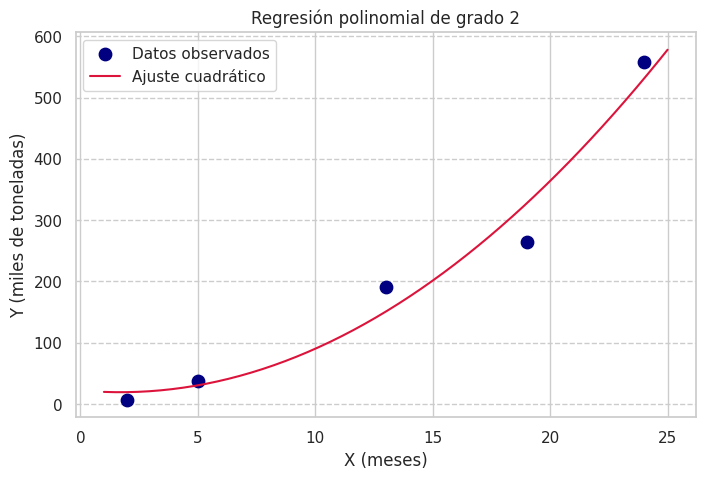

X= 2  Y=   7  Y_hat=  19.408  residuo= -12.408
X= 5  Y=  38  Y_hat=  30.542  residuo=   7.458
X=13  Y= 191  Y_hat= 150.748  residuo=  40.252
X=19  Y= 265  Y_hat= 327.302  residuo= -62.302
X=24  Y= 558  Y_hat= 531.001  residuo=  26.999


In [10]:
Y_hat = a_hat + b_hat * X + c_hat * X**2

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color="navy", s=80, label="Datos observados")
x_plot = np.linspace(X.min() - 1, X.max() + 1, 200)
y_plot = a_hat + b_hat * x_plot + c_hat * x_plot**2
plt.plot(x_plot, y_plot, color="crimson", label="Ajuste cuadrático")
plt.xlabel("X (meses)")
plt.ylabel("Y (miles de toneladas)")
plt.title("Regresión polinomial de grado 2")
plt.legend()
plt.grid(axis="y", ls="--")
plt.show()

for xi, yi, ypi in zip(X, Y, Y_hat):
    print(f"X={xi:2d}  Y={yi:4d}  Y_hat={ypi:8.3f}  residuo={yi - ypi:8.3f}")

---
## Ejercicio 3 — Inferencia bayesiana (4 puntos)

Don Francisco tiene $n=10$ clientes y exactamente $k=1$ está en mora.

### Paso 1 — Definir el parámetro y el prior

Sea $p$ la proporción de morosidad. El prior elegido por Matías es:

$$p \sim \text{Beta}(\alpha, \beta) = \text{Beta}(1, 3)$$

Su densidad es:

$$\pi(p) = \frac{\Gamma(4)}{\Gamma(1)\Gamma(3)}\, p^{1-1}(1-p)^{3-1} = 3(1-p)^2, \qquad 0 < p < 1$$

### Paso 2 — Escribir la verosimilitud

Condicionado en $p$, el número de clientes en mora sigue una binomial:

$$k \mid p \sim \text{Binomial}(n, p), \qquad n = 10, \; k = 1$$

$$L(p) = P(k=1 \mid p) = \binom{10}{1} p^{1}(1-p)^{10-1} = 10\,p(1-p)^9$$

### Paso 3 — Aplicar el teorema de Bayes

La densidad a posteriori es proporcional a prior $\times$ verosimilitud:

$$\pi(p \mid k) \propto \pi(p)\,L(p)$$

$$\pi(p \mid k) \propto p^{\alpha-1}(1-p)^{\beta-1} \cdot p^{k}(1-p)^{n-k}$$

$$\pi(p \mid k) \propto p^{\alpha+k-1}(1-p)^{\beta+n-k-1}$$

Como la forma es la de una Beta, la posterior es:

$$p \mid k \sim \text{Beta}(\alpha + k,\; \beta + n - k)$$

### Paso 4 — Sustituir los valores observados

$$\alpha + k = 1 + 1 = 2$$

$$\beta + n - k = 3 + 10 - 1 = 12$$

$$p \mid k \sim \text{Beta}(2, 12)$$

### Paso 5 — Calcular la media a posteriori

Para $Z \sim \text{Beta}(\alpha, \beta)$, se cumple:

$$\mathbb{E}[Z] = \frac{\alpha}{\alpha + \beta}$$

Con $\alpha = 2$ y $\beta = 12$:

$$\mathbb{E}[p \mid k] = \frac{2}{2 + 12} = \frac{2}{14} = \frac{1}{7}$$

$$\mathbb{E}[p \mid k] \approx 0{,}1429 \; (14{,}3\%)$$

### Paso 6 — Calcular la varianza a posteriori

Para $Z \sim \text{Beta}(\alpha, \beta)$:

$$\text{Var}(Z) = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$$

Primero calculamos $\alpha + \beta$:

$$\alpha + \beta = 2 + 12 = 14$$

$$\alpha + \beta + 1 = 15$$

El numerador es:

$$\alpha\beta = 2 \cdot 12 = 24$$

El denominador es:

$$(\alpha+\beta)^2(\alpha+\beta+1) = 14^2 \cdot 15 = 196 \cdot 15 = 2940$$

Entonces:

$$\text{Var}(p \mid k) = \frac{24}{2940} = \frac{2}{245}$$

$$\text{Var}(p \mid k) \approx 0{,}00816$$

El desvío estándar a posteriori es:

$$\sqrt{\text{Var}(p \mid k)} = \sqrt{\frac{2}{245}} \approx 0{,}0904 \; (9{,}0\%)$$

In [11]:
alpha_prior, beta_prior = 1, 3
n_clientes, k_mora = 10, 1

alpha_post = alpha_prior + k_mora
beta_post = beta_prior + n_clientes - k_mora

media_post = alpha_post / (alpha_post + beta_post)
var_post = (alpha_post * beta_post) / ((alpha_post + beta_post) ** 2 * (alpha_post + beta_post + 1))
desv_post = np.sqrt(var_post)

print(f"Prior: Beta({alpha_prior}, {beta_prior})")
print(f"Posterior: Beta({alpha_post}, {beta_post})")
print(f"Media posterior: {media_post:.6f} ({media_post:.1%})")
print(f"Varianza posterior: {var_post:.6f}")
print(f"Desvío estándar posterior: {desv_post:.6f}")

Prior: Beta(1, 3)
Posterior: Beta(2, 12)
Media posterior: 0.142857 (14.3%)
Varianza posterior: 0.008163
Desvío estándar posterior: 0.090351


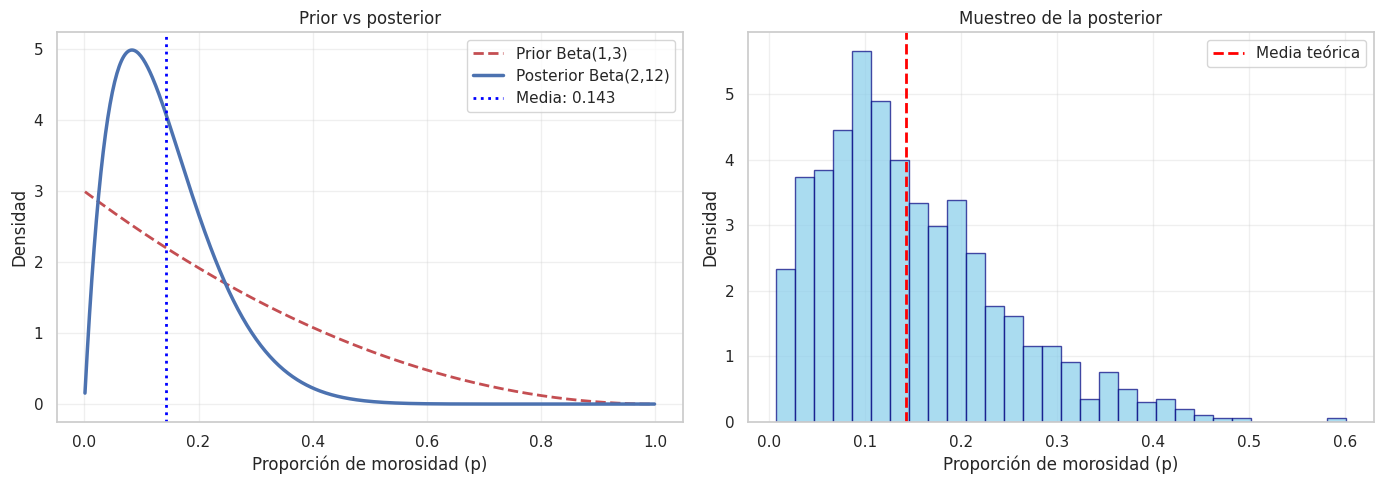

In [12]:
x = np.linspace(0.001, 0.999, 500)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

prior_pdf = beta.pdf(x, alpha_prior, beta_prior)
post_pdf = beta.pdf(x, alpha_post, beta_post)

ax[0].plot(x, prior_pdf, "r--", linewidth=2, label=f"Prior Beta({alpha_prior},{beta_prior})")
ax[0].plot(x, post_pdf, "b-", linewidth=2.5, label=f"Posterior Beta({alpha_post},{beta_post})")
ax[0].axvline(media_post, color="blue", linestyle=":", linewidth=2, label=f"Media: {media_post:.3f}")
ax[0].set_xlabel("Proporción de morosidad (p)")
ax[0].set_ylabel("Densidad")
ax[0].set_title("Prior vs posterior")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

muestras = beta.rvs(alpha_post, beta_post, size=1000)
ax[1].hist(muestras, bins=30, density=True, alpha=0.7, color="skyblue", edgecolor="navy")
ax[1].axvline(media_post, color="red", linestyle="--", linewidth=2, label="Media teórica")
ax[1].set_xlabel("Proporción de morosidad (p)")
ax[1].set_ylabel("Densidad")
ax[1].set_title("Muestreo de la posterior")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación

Tras observar $1$ cliente en mora entre $10$, la creencia actualizada sobre $p$ queda concentrada alrededor de $14{,}3\%$, con desvío estándar aproximado de $9{,}0\%$. La posterior incorpora tanto el prior optimista ($\text{Beta}(1,3)$, que favorece morosidad baja) como la evidencia muestral.